# S6 — Tempering (ntemp / alpha_s) Sensitivity & Failure-Mode Characterization

**Scope.** The cluster rerun that adds `crps`/`skew`/`kurt` to the *posterior*-side
tuning sweep output is still in progress, so this notebook works with what's on
disk now: the existing RMSE/spread sweep output (6 configs — events 1800/1900/2000 UTC
x 5min/1hr background lead time, full `ntemp=1..10` x `alpha_s` grid, 60 truth
members each) plus **prior-side** CRPS/skew/kurt, which is fully computable now
without any rerun (the prior ensemble is identical across every ntemp/alpha_s
combo for a given truth member — see `_setup()` in `src/runners/run_experiment.py`).
Posterior CRPS/skew/kurt is left as a placeholder (Section 14) for once the
rerun lands.

**Known data-quality issue.** All 6 `configs/ws_tuning_5min_*.yaml` have a YAML
typo: `alpha_s: [..., 0.5, 0,7, 1.0, ...]` parses as separate `0` and `7`
instead of the intended `0.7`. This notebook works around it: duplicate
`alpha_s=0.0` rows are deduped, `alpha_s=7.0` is kept as a real (extreme) data
point, and the gap at the never-tested `0.7` is called out where relevant.

**Sections**
1. Setup & config discovery
2. Data-quality demo (dedup counts, AOEI redundancy, `_1hrs` filename collision)
3. Tempering schedule sanity check
4. Tier-1 load & full-grid aggregation (all 6 configs x 60 truth members)
5. Sensitivity to `ntemp` and `alpha_s` (full grid)
6. Phase-space characterization (where tempering helps/hurts vs LETKF and vs prior)
7. Representative-subset selection
8. Tier-2 reload (representative combos, full resolution)
9. Prior CRPS/skew/kurt precompute (no rerun needed)
10. Non-Gaussianity hypothesis test
11. Spatial characterization
12. 5min vs 1hr prior comparison
13. Final recommendation summary
14. Placeholder — posterior CRPS/skew/kurt (pending rerun)


In [1]:

import glob
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import binned_statistic_2d

plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': 0.3})

REPO = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation"
sys.path.insert(0, os.path.join(REPO, "src"))

from da.core import tempering_schedule
from da.metrics import ensemble_skew, ensemble_kurt, crps_ensemble_sorted
from runners.run_experiment import _calc_hx_domain

CACHE_DIR = os.path.join(REPO, "data", "derived_S6_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

VAR_IDX = {'qg': 0, 'qr': 1, 'qs': 2, 'T': 3, 'P': 4, 'u': 5, 'v': 6, 'w': 7}
EVENTS = [1800, 1900, 2000]
LEAD_TIMES = ["5min", "1hr"]

print("Setup OK. Cache dir:", CACHE_DIR)


Setup OK. Cache dir: /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/derived_S6_cache


In [2]:

def _localize(p):
    '''Config yamls hardcode an absolute path under a mount alias
    (/home/jorge.gacitua/salidas/...) not visible from this session; only
    /home/jorge.gacitua/datosmunin/... is. Translate by keeping everything
    from 'WRF_Single_Cycle_Assimilation/' onward and rejoining onto REPO —
    same fix as the queue_ws.sh REPO-path mismatch documented for this
    project (compute nodes vs. this session see different mounts of the
    same underlying storage).'''
    marker = "WRF_Single_Cycle_Assimilation/"
    idx = p.index(marker) + len(marker)
    return os.path.join(REPO, p[idx:])


def discover_configs():
    cfgs = {}
    for f in sorted(glob.glob(os.path.join(REPO, "configs", "ws_tuning_5min_*.yaml"))):
        with open(f) as fh:
            y = yaml.safe_load(fh)
        base = os.path.basename(f).replace("ws_tuning_5min_", "").replace(".yaml", "")
        is_1hr = base.endswith("_1hrs")
        event = int(base.replace("_1hrs", ""))
        lead_time = "1hr" if is_1hr else "5min"
        cfgs[(event, lead_time)] = dict(
            config_path=f,
            sweep_dir=_localize(y["paths"]["outdir"]),
            prior_npz=_localize(y["paths"]["prepared"]),
            ntemp_grid=y["sweep"]["ntemp"],
            alpha_grid_raw=y["sweep"]["alpha_s"],
            methods=y["sweep"]["methods"],
            stride=int(y["sweep"]["stride"]),
        )
    return cfgs


CONFIGS = discover_configs()
for k, v in CONFIGS.items():
    print(k, "->", v["sweep_dir"])


(1800, '5min') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1800/
(1800, '1hr') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1800_1hrs/
(1900, '5min') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1900/
(1900, '1hr') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1900_1hrs/
(2000, '5min') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_2000/
(2000, '1hr') -> /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_2000_1hrs/


## 1. Data-quality demo

Demonstrates, on real data, the three loader workarounds this notebook relies
on: (a) `alpha_s=0.0` duplicate rows from the YAML typo, (b) AOEI's redundant
`alpha_s` dimension (AOEI ignores `alpha_s` entirely), (c) the `_1hrs`
configs' output-filename collision with their base-config siblings (same
`experiment_tag`, only the parent directory differs).

In [3]:

POINT_COLS = ['i', 'j', 'k', 'x_km', 'y_km', 'z_km', 'yo', 'yo_clean', 'hxf_mean_obs',
              'dep_b', 'spread_f_obs', 'rmse_f_point_obs', 'hx_dbz_local_mean_w',
              'hx_dbz_local_mean_u', 'precip_fraction_f',
              'rmse_f_point_qg', 'spread_f_point_qg']
COMBO_COLS = ['i', 'j', 'k', 'method', 'ntemp', 'alpha_s', 'hxa_mean_obs', 'dep_a',
              'spread_a_obs', 'rmse_a_point_obs', 'rmse_a_point_qg']
ALL_KEYS = sorted(set(POINT_COLS) | set(COMBO_COLS))
ID_COLS = ['i', 'j', 'k', 'method', 'ntemp', 'alpha_s']


def load_one_file(npz_path):
    '''Load, dedupe, and split one sweep npz into a per-point 'forecast' table
    (combo-invariant columns, since the prior xf is built once per truth member
    before the ntemp/alpha_s/method loop) and a per-(point,combo) 'analysis'
    table. See _setup() in src/runners/run_experiment.py:114.'''
    with np.load(npz_path) as data:
        cols = {k: data[k] for k in ALL_KEYS}
    df = pd.DataFrame(cols)
    df['method'] = df['method'].astype(str)

    n_raw = len(df)
    df = df.drop_duplicates(subset=ID_COLS).reset_index(drop=True)
    n_dedup = len(df)

    # AOEI ignores alpha_s -> every alpha_s row is a duplicate; keep one canonical row/point
    is_aoei = df['method'] == 'AOEI'
    df = df[(~is_aoei) | (is_aoei & (df['alpha_s'] == 0.0))].reset_index(drop=True)
    n_aoei = len(df)

    # At ntemp=1, tempering_schedule ignores alpha_s -> every alpha_s row is
    # bit-identical per point; keep a single canonical alpha_s=0.0 row for the
    # LETKF baseline downstream (not just any ntemp==1 row, which is still 10/point).
    point_df = (df[(df['ntemp'] == 1) & (df['method'] == 'TEnKF') & (df['alpha_s'] == 0.0)]
                [POINT_COLS].drop_duplicates(subset=['i', 'j', 'k']).reset_index(drop=True))
    combo_df = df[COMBO_COLS].reset_index(drop=True)
    return point_df, combo_df, dict(n_raw=n_raw, n_dedup=n_dedup, n_aoei=n_aoei)


# --- demo on tm00/1800 ---
ev, lt = 1800, "5min"
f0 = os.path.join(CONFIGS[(ev, lt)]['sweep_dir'], "WS_tune_5min_1800_sweep_Ne059_tm00.npz")
point_df0, combo_df0, stats0 = load_one_file(f0)
print(f"[{ev} {lt}] tm00: raw={stats0['n_raw']} -> dedup={stats0['n_dedup']} "
      f"(-{stats0['n_raw']-stats0['n_dedup']} alpha=0.0 dups) "
      f"-> after AOEI fix={stats0['n_aoei']} (-{stats0['n_dedup']-stats0['n_aoei']} AOEI dups)")
print("QC points:", len(point_df0), " distinct alpha_s after fix:", sorted(combo_df0['alpha_s'].unique()))
print("(intended alpha_s=0.7 never tested; 7.0 kept as a real extreme point)")

# --- _1hrs filename collision demo ---
f_5min = os.path.join(CONFIGS[(1800, '5min')]['sweep_dir'], "WS_tune_5min_1800_sweep_Ne059_tm00.npz")
f_1hr = os.path.join(CONFIGS[(1800, '1hr')]['sweep_dir'], "WS_tune_5min_1800_sweep_Ne059_tm00.npz")
print()
print("5min file:", f_5min)
print("1hr  file:", f_1hr)
print("Same basename, different directory:", os.path.basename(f_5min) == os.path.basename(f_1hr),
      "/ different parent:", os.path.dirname(f_5min) != os.path.dirname(f_1hr))


[1800 5min] tm00: raw=1001400 -> dedup=917950 (-83450 alpha=0.0 dups) -> after AOEI fix=842845 (-75105 AOEI dups)
QC points: 8345  distinct alpha_s after fix: [0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 7.0]
(intended alpha_s=0.7 never tested; 7.0 kept as a real extreme point)

5min file: /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1800/WS_tune_5min_1800_sweep_Ne059_tm00.npz
1hr  file: /home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS_tune_5min_1800_1hrs/WS_tune_5min_1800_sweep_Ne059_tm00.npz
Same basename, different directory: True / different parent: True


## 2. Tempering schedule sanity check

`tempering_schedule(ntemp, alpha_s)` (`src/da/core.py:40`) computes back-loaded
exponential weights: `w_i = exp(-(ntemp+1)*alpha_s/i)`, normalized. At
`ntemp=1` it always returns `[1.0]` regardless of `alpha_s` (plain LETKF). As
`alpha_s` grows, weight shifts toward the final step (early steps become
near-no-ops, inflating R almost to infinity there).

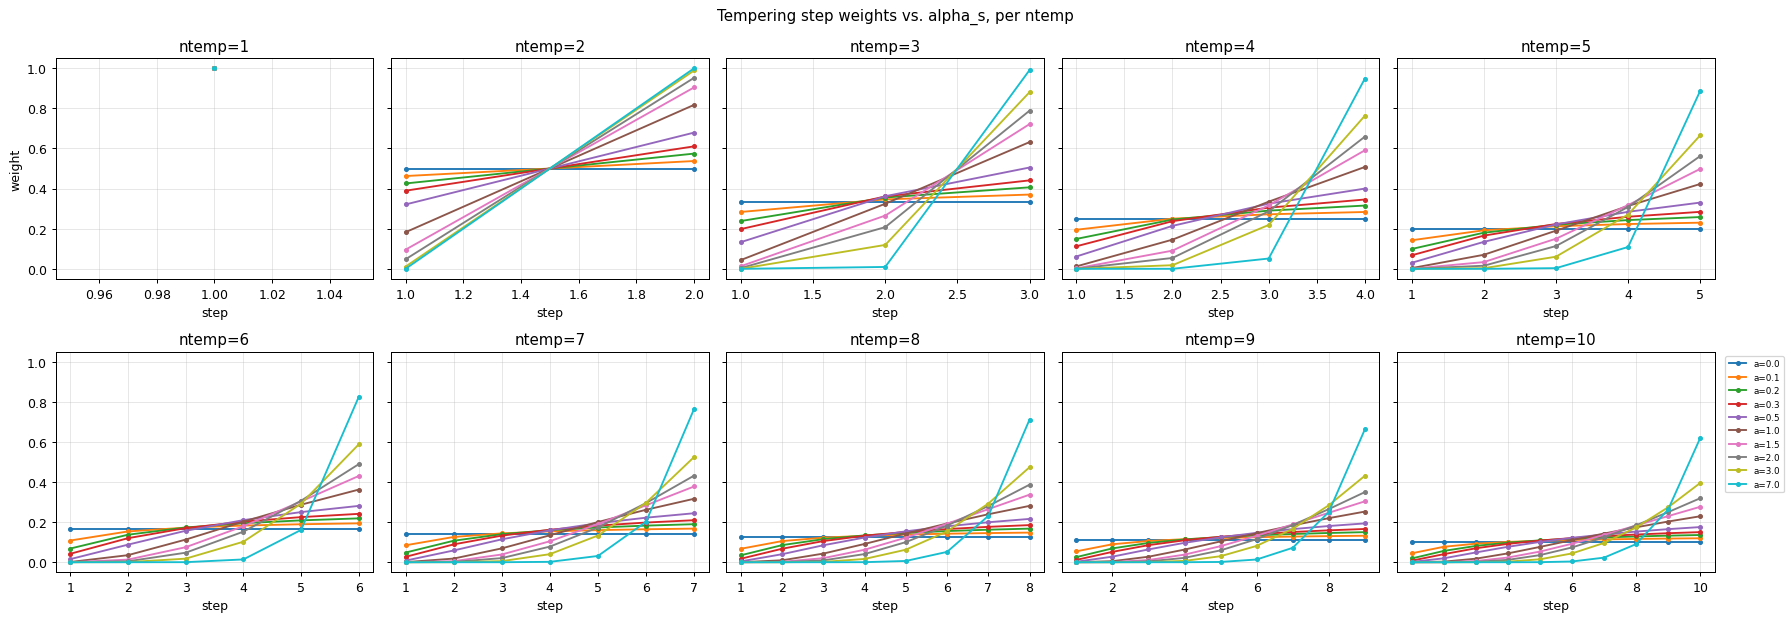

ntemp=1 sanity: schedule ignores alpha_s -> True


In [4]:

alpha_grid = sorted(set(a for cfg in CONFIGS.values() for a in cfg['alpha_grid_raw'] if isinstance(a, (int, float))))
alpha_grid = [a for a in alpha_grid if a != 0]  # the stray bare "0,7" typo elements handled at load time
alpha_grid = sorted(set([0.0, 0.1, 0.2, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 7.0]))
ntemp_grid = list(range(1, 11))

fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=True)
for ax, nt in zip(axes.flat, ntemp_grid):
    for a in alpha_grid:
        w = tempering_schedule(nt, a)
        ax.plot(np.arange(1, nt + 1), w, marker='o', ms=3, label=f'a={a}')
    ax.set_title(f'ntemp={nt}')
    ax.set_xlabel('step')
if True:
    axes.flat[0].set_ylabel('weight')
    axes.flat[-1].legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.suptitle('Tempering step weights vs. alpha_s, per ntemp')
plt.tight_layout()
plt.show()

print("ntemp=1 sanity: schedule ignores alpha_s ->",
      all(np.allclose(tempering_schedule(1, a), [1.0]) for a in alpha_grid))


## 4. Tier-1 load & full-grid aggregation

Streams through all 6 configs x 60 truth-member files (360 files total). Per
file: merge the point/forecast table into the combo/analysis table, compute
`delta_letkf`, `delta_prior`, and the outcome category, then reduce to (a) a
per-combo summary and (b) a 2D phase-space-binned summary (on
`(yo_clean, hxf_mean_obs)`) — both tagged by `(event, lead_time, tm)` — before
discarding the merged table. This keeps peak memory to one file's data at a
time; final aggregation across the 360 per-file summaries takes an
**equal-weighted mean across the 60 truth members** (not a pooled per-point
mean — points within one truth member are spatially correlated, so truth
members are the actual independent replicates here).

**Comparison formulas** (using `rmse_*_point_obs`, relative to clean truth —
not `dep_*`, which is relative to the noisy obs and is reserved for residual
plots):
- `delta_letkf = rmse_a_point_obs(ntemp=1) - rmse_a_point_obs(combo)` — positive = better than LETKF
- `delta_prior = rmse_f_point_obs - rmse_a_point_obs(combo)` — positive = net improvement over doing nothing
- Outcome category: **A** better-than-both, **B** worse-than-LETKF-but-better-than-prior,
  **C** better-than-LETKF... worse-than-prior (partial repair), **D** worse-than-both (the
  "worse than doing nothing" failure mode).

In [5]:

BINS = [np.arange(-3, 73, 2.5), np.arange(-3, 33, 2.5)]  # (yo_clean, hxf_mean_obs) — from parameters_tunning.ipynb cell 19
BIN_LABELS_X = [(BINS[0][i] + BINS[0][i+1]) / 2 for i in range(len(BINS[0]) - 1)]
BIN_LABELS_Y = [(BINS[1][i] + BINS[1][i+1]) / 2 for i in range(len(BINS[1]) - 1)]


def process_file(point_df, combo_df):
    m = combo_df.merge(
        point_df[['i', 'j', 'k', 'yo_clean', 'hxf_mean_obs', 'rmse_f_point_obs']],
        on=['i', 'j', 'k'], how='left')

    letkf = (m[(m.method == 'TEnKF') & (m.ntemp == 1) & (m.alpha_s == 0.0)]
              .set_index(['i', 'j', 'k'])['rmse_a_point_obs'])
    m['rmse_a_letkf'] = m.set_index(['i', 'j', 'k']).index.map(letkf)

    m['delta_letkf'] = m['rmse_a_letkf'] - m['rmse_a_point_obs']
    m['delta_prior'] = m['rmse_f_point_obs'] - m['rmse_a_point_obs']
    m['category'] = np.where(m.delta_letkf > 0,
                              np.where(m.delta_prior > 0, 'A', 'C'),
                              np.where(m.delta_prior > 0, 'B', 'D'))

    combo_summary = m.groupby(['method', 'ntemp', 'alpha_s']).agg(
        mean_delta_letkf=('delta_letkf', 'mean'),
        mean_delta_prior=('delta_prior', 'mean'),
        n=('delta_letkf', 'size'),
    ).reset_index()
    for c in ['A', 'B', 'C', 'D']:
        frac = m.groupby(['method', 'ntemp', 'alpha_s'])['category'].apply(lambda s: (s == c).mean())
        combo_summary[f'frac_{c}'] = combo_summary.set_index(['method', 'ntemp', 'alpha_s']).index.map(frac).values

    tenkf = m[m.method == 'TEnKF'].copy()
    tenkf['bin_x'] = np.digitize(tenkf['yo_clean'], BINS[0]) - 1
    tenkf['bin_y'] = np.digitize(tenkf['hxf_mean_obs'], BINS[1]) - 1
    valid = (tenkf['bin_x'] >= 0) & (tenkf['bin_x'] < len(BIN_LABELS_X)) & \
            (tenkf['bin_y'] >= 0) & (tenkf['bin_y'] < len(BIN_LABELS_Y))
    tenkf = tenkf[valid]
    bin_summary = tenkf.groupby(['bin_x', 'bin_y', 'ntemp', 'alpha_s']).agg(
        mean_delta_letkf=('delta_letkf', 'mean'),
        mean_delta_prior=('delta_prior', 'mean'),
        frac_D=('category', lambda s: (s == 'D').mean()),
        n=('delta_letkf', 'size'),
    ).reset_index()

    return combo_summary, bin_summary


def run_tier1_for_config(event, lead_time, verbose_every=15):
    cfg = CONFIGS[(event, lead_time)]
    files = sorted(glob.glob(os.path.join(cfg['sweep_dir'], "*_sweep_*_tm*.npz")))
    combo_list, bin_list = [], []
    for n_done, f in enumerate(files):
        tm = int(os.path.basename(f).split('_tm')[-1].replace('.npz', ''))
        point_df, combo_df, _ = load_one_file(f)
        cs, bs = process_file(point_df, combo_df)
        cs['tm'] = tm
        bs['tm'] = tm
        combo_list.append(cs)
        bin_list.append(bs)
        if (n_done + 1) % verbose_every == 0:
            print(f"  [{event} {lead_time}] {n_done+1}/{len(files)} files")
    combo_all = pd.concat(combo_list, ignore_index=True)
    bin_all = pd.concat(bin_list, ignore_index=True)
    combo_all['event'] = event
    combo_all['lead_time'] = lead_time
    bin_all['event'] = event
    bin_all['lead_time'] = lead_time
    return combo_all, bin_all


print("Tier-1 functions ready.")


Tier-1 functions ready.


In [6]:

COMBO_CACHE = os.path.join(CACHE_DIR, "tier1_combo_summary.pkl")
BIN_CACHE = os.path.join(CACHE_DIR, "tier1_bin_summary.pkl")

if os.path.exists(COMBO_CACHE) and os.path.exists(BIN_CACHE):
    print("Loading Tier-1 summaries from cache...")
    combo_summary_raw = pd.read_pickle(COMBO_CACHE)
    bin_summary_raw = pd.read_pickle(BIN_CACHE)
else:
    t0 = time.time()
    combo_parts, bin_parts = [], []
    for event in EVENTS:
        for lead_time in LEAD_TIMES:
            print(f"=== {event} {lead_time} ===")
            c, b = run_tier1_for_config(event, lead_time)
            combo_parts.append(c)
            bin_parts.append(b)
    combo_summary_raw = pd.concat(combo_parts, ignore_index=True)
    bin_summary_raw = pd.concat(bin_parts, ignore_index=True)
    combo_summary_raw.to_pickle(COMBO_CACHE)
    bin_summary_raw.to_pickle(BIN_CACHE)
    print(f"Tier-1 done in {time.time()-t0:.0f}s. combo_summary_raw={combo_summary_raw.shape}, "
          f"bin_summary_raw={bin_summary_raw.shape}")

print(combo_summary_raw.shape, bin_summary_raw.shape)


=== 1800 5min ===
  [1800 5min] 15/60 files
  [1800 5min] 30/60 files
  [1800 5min] 45/60 files
  [1800 5min] 60/60 files
=== 1800 1hr ===
  [1800 1hr] 15/60 files
  [1800 1hr] 30/60 files
  [1800 1hr] 45/60 files
  [1800 1hr] 60/60 files
=== 1900 5min ===
  [1900 5min] 15/60 files
  [1900 5min] 30/60 files
  [1900 5min] 45/60 files
  [1900 5min] 60/60 files
=== 1900 1hr ===
  [1900 1hr] 15/60 files
  [1900 1hr] 30/60 files
  [1900 1hr] 45/60 files
  [1900 1hr] 60/60 files
=== 2000 5min ===
  [2000 5min] 15/60 files
  [2000 5min] 30/60 files
  [2000 5min] 45/60 files
  [2000 5min] 60/60 files
=== 2000 1hr ===
  [2000 1hr] 15/60 files
  [2000 1hr] 30/60 files
  [2000 1hr] 45/60 files
  [2000 1hr] 60/60 files
Tier-1 done in 1954s. combo_summary_raw=(36360, 13), bin_summary_raw=(3844700, 11)
(36360, 13) (3844700, 11)


In [7]:

# Equal-weighted mean across the 60 truth members (per event, lead_time, combo)
final_combo = combo_summary_raw.groupby(['event', 'lead_time', 'method', 'ntemp', 'alpha_s']).agg(
    mean_delta_letkf=('mean_delta_letkf', 'mean'),
    se_delta_letkf=('mean_delta_letkf', 'sem'),
    mean_delta_prior=('mean_delta_prior', 'mean'),
    se_delta_prior=('mean_delta_prior', 'sem'),
    frac_A=('frac_A', 'mean'), frac_B=('frac_B', 'mean'),
    frac_C=('frac_C', 'mean'), frac_D=('frac_D', 'mean'),
    n_tm=('mean_delta_letkf', 'size'),
).reset_index()

final_bin = bin_summary_raw.groupby(['event', 'lead_time', 'bin_x', 'bin_y', 'ntemp', 'alpha_s']).agg(
    mean_delta_letkf=('mean_delta_letkf', 'mean'),
    mean_delta_prior=('mean_delta_prior', 'mean'),
    frac_D=('frac_D', 'mean'),
    n_tm=('mean_delta_letkf', 'size'),
).reset_index()

print("Sanity: at ntemp=1, mean_delta_letkf should be ~0 for every alpha_s/event/lead_time:")
sanity = final_combo[(final_combo.ntemp == 1) & (final_combo.method == 'TEnKF')]
print("max |mean_delta_letkf| at ntemp=1:", sanity['mean_delta_letkf'].abs().max())

final_combo.head()


Sanity: at ntemp=1, mean_delta_letkf should be ~0 for every alpha_s/event/lead_time:
max |mean_delta_letkf| at ntemp=1: 0.0


,event,lead_time,method,ntemp,alpha_s,mean_delta_letkf,se_delta_letkf,mean_delta_prior,se_delta_prior,frac_A,frac_B,frac_C,frac_D,n_tm
0,1800,1hr,AOEI,1,0.0,-0.183571,0.011936,-0.761652,0.014157,0.011276,0.778264,0.036028,0.174432,60
1,1800,1hr,TEnKF,1,0.0,0.000000,0.000000,-0.578081,0.023208,0.000000,0.785617,0.000000,0.214383,60
2,1800,1hr,TEnKF,1,0.1,0.000000,0.000000,-0.578081,0.023208,0.000000,0.785617,0.000000,0.214383,60
3,1800,1hr,TEnKF,1,0.2,0.000000,0.000000,-0.578081,0.023208,0.000000,0.785617,0.000000,0.214383,60
4,1800,1hr,TEnKF,1,0.3,0.000000,0.000000,-0.578081,0.023208,0.000000,0.785617,0.000000,0.214383,60


## 5. Sensitivity to `ntemp` and `alpha_s` (full grid)

Heatmaps of mean `delta_letkf`/`delta_prior` over the full `(ntemp, alpha_s)`
grid, per `(event, lead_time)`, plus marginal line plots. The odd/even
`ntemp` parity oscillation documented in `test/diagnose_nt_parity.py`
(driven by the qr/qs/qg >= 0 clipping applied after every tempering
sub-step) shows up here as a sawtooth — expected, not noise.

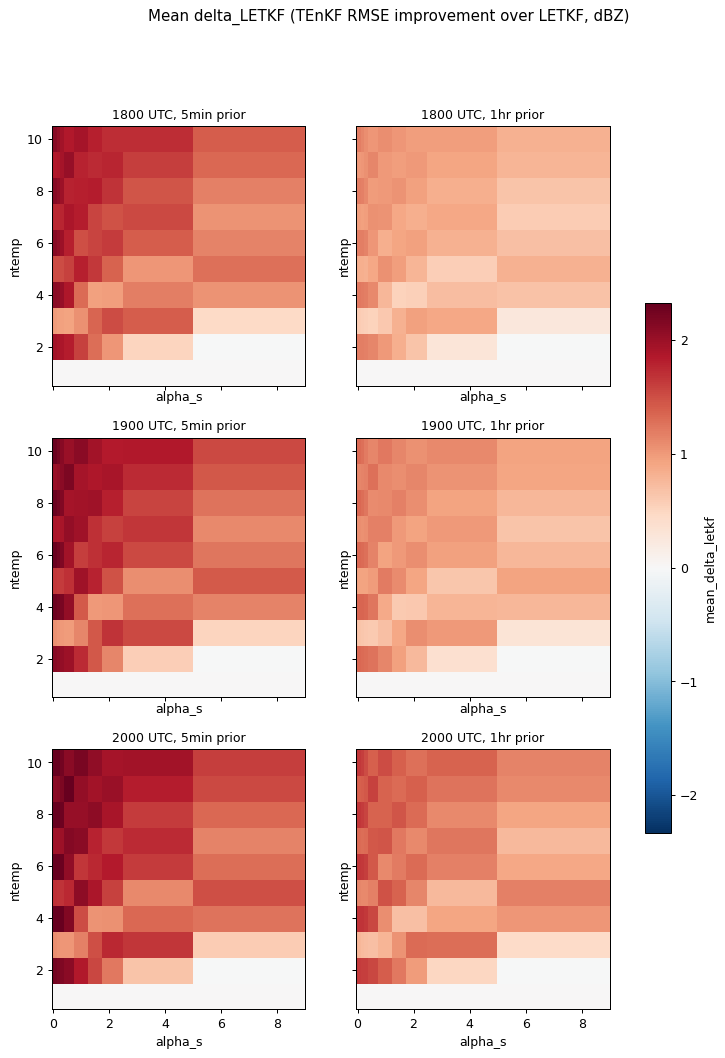

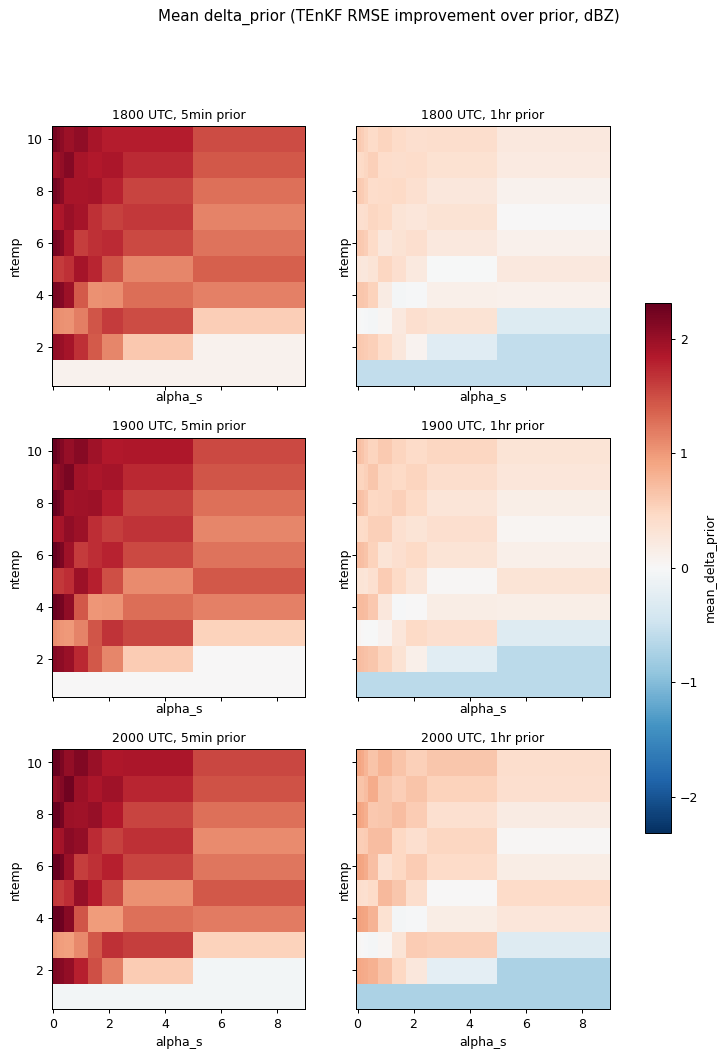

In [8]:

def plot_heatmap_grid(df, value_col, title):
    fig, axes = plt.subplots(len(EVENTS), len(LEAD_TIMES), figsize=(10, 13), sharex=True, sharey=True)
    vmax = df[value_col].abs().quantile(0.98)
    norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    for ri, event in enumerate(EVENTS):
        for ci, lt in enumerate(LEAD_TIMES):
            ax = axes[ri][ci]
            sub = df[(df.event == event) & (df.lead_time == lt) & (df.method == 'TEnKF')]
            piv = sub.pivot(index='ntemp', columns='alpha_s', values=value_col)
            im = ax.pcolormesh(piv.columns, piv.index, piv.values, cmap='RdBu_r', norm=norm, shading='nearest')
            ax.set_title(f'{event} UTC, {lt} prior', fontsize=10)
            ax.set_xlabel('alpha_s')
            ax.set_ylabel('ntemp')
    fig.colorbar(im, ax=axes, shrink=0.6, label=value_col)
    fig.suptitle(title)
    plt.show()


plot_heatmap_grid(final_combo, 'mean_delta_letkf', 'Mean delta_LETKF (TEnKF RMSE improvement over LETKF, dBZ)')
plot_heatmap_grid(final_combo, 'mean_delta_prior', 'Mean delta_prior (TEnKF RMSE improvement over prior, dBZ)')


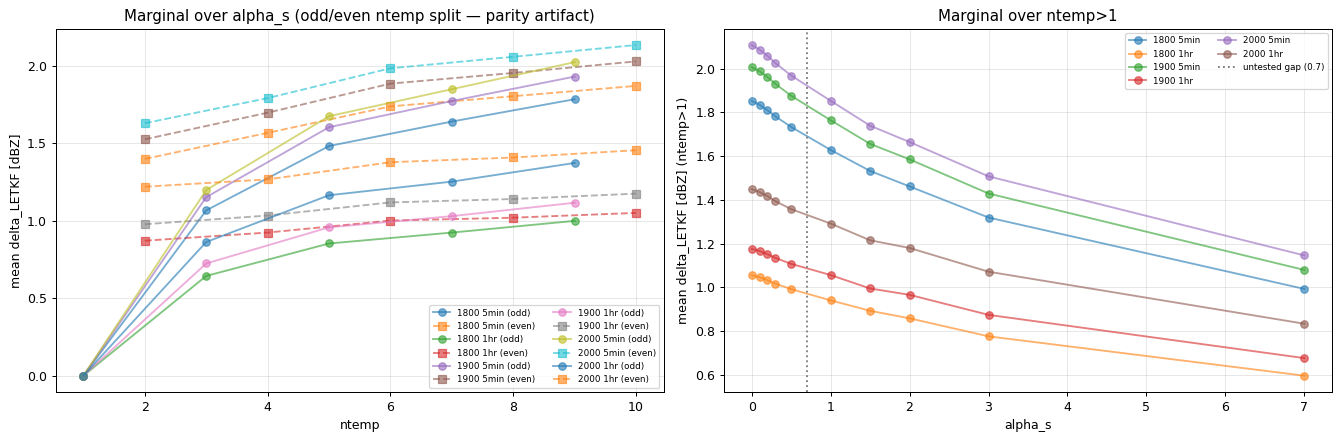

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for event in EVENTS:
    for lt in LEAD_TIMES:
        sub = final_combo[(final_combo.event == event) & (final_combo.lead_time == lt) &
                           (final_combo.method == 'TEnKF')]
        marg_ntemp = sub.groupby('ntemp')['mean_delta_letkf'].mean()
        odd = marg_ntemp.index % 2 == 1
        axes[0].plot(marg_ntemp.index[odd], marg_ntemp.values[odd], 'o-', alpha=0.6,
                     label=f'{event} {lt} (odd)')
        axes[0].plot(marg_ntemp.index[~odd], marg_ntemp.values[~odd], 's--', alpha=0.6,
                     label=f'{event} {lt} (even)')

        marg_alpha = sub[sub.ntemp > 1].groupby('alpha_s')['mean_delta_letkf'].mean()
        axes[1].plot(marg_alpha.index, marg_alpha.values, 'o-', alpha=0.6, label=f'{event} {lt}')

axes[0].set_xlabel('ntemp'); axes[0].set_ylabel('mean delta_LETKF [dBZ]')
axes[0].set_title('Marginal over alpha_s (odd/even ntemp split — parity artifact)')
axes[0].legend(fontsize=7, ncol=2)
axes[1].axvline(0.7, color='gray', ls=':', label='untested gap (0.7)')
axes[1].set_xlabel('alpha_s'); axes[1].set_ylabel('mean delta_LETKF [dBZ] (ntemp>1)')
axes[1].set_title('Marginal over ntemp>1')
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 6. Phase-space characterization

Where in `(yo_clean, hxf_mean_obs)` space does tempering help/hurt, relative
to LETKF and relative to the prior? Adapts the `plot_rmse_penalty` /
`binned_statistic_2d` pattern from `parameters_tunning.ipynb` cells 17-19,
but runs off the Tier-1 pre-aggregated bins instead of a giant in-memory
per-point frame. `frac_D` (Category-D rate, i.e. worse-than-both) is the
primary "where does tempering fail" signal.

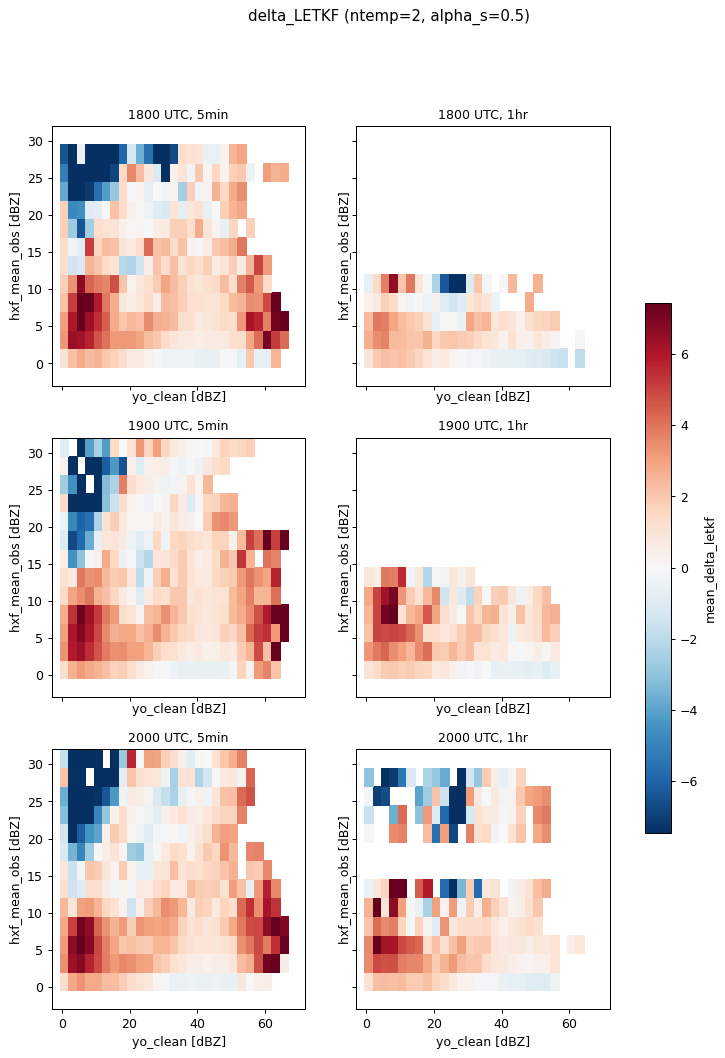

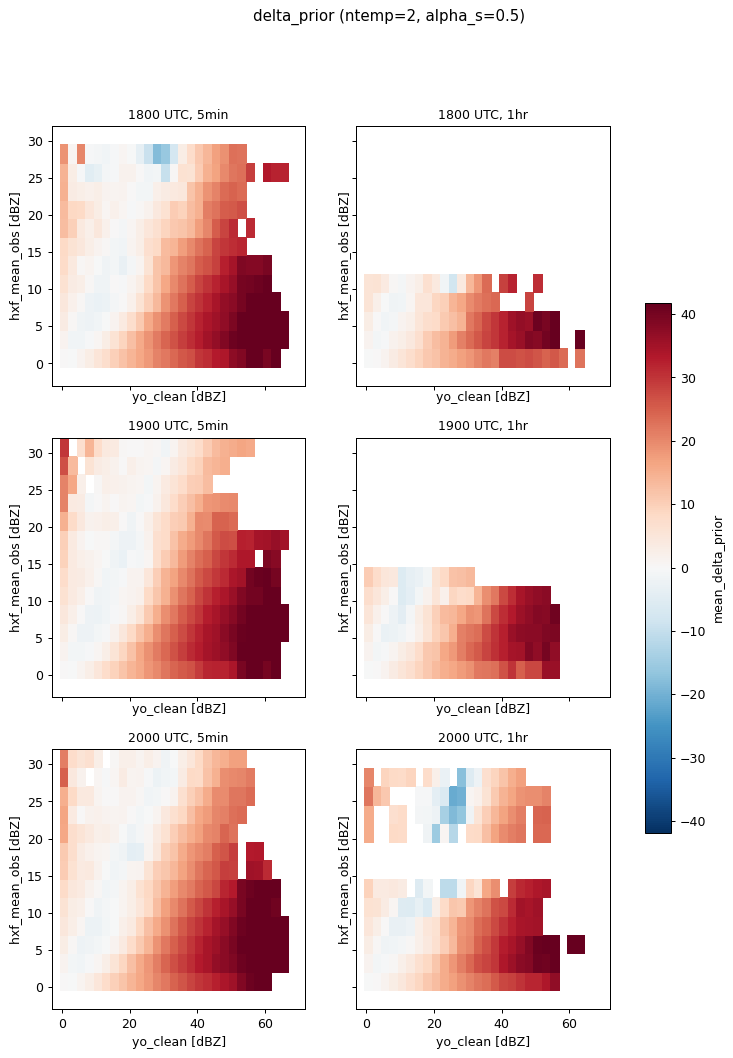

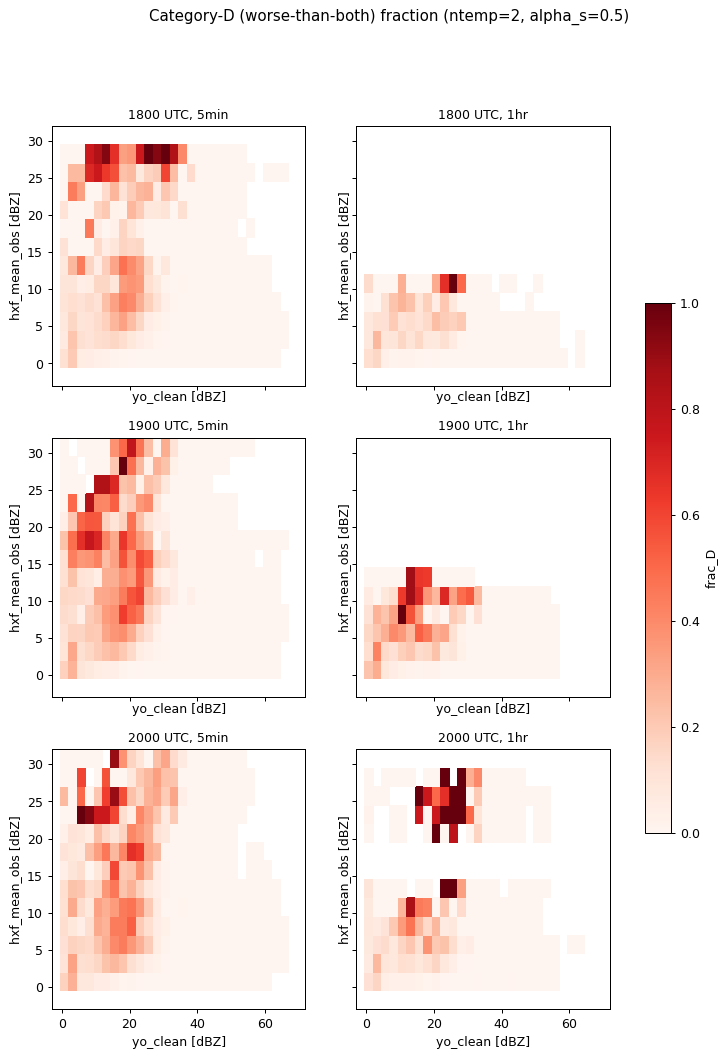

In [10]:

def phase_space_heatmap(df, value_col, ntemp, alpha_s, title, cmap='RdBu_r', vcenter=0):
    fig, axes = plt.subplots(len(EVENTS), len(LEAD_TIMES), figsize=(10, 13), sharex=True, sharey=True)
    sub_all = df[(df.ntemp == ntemp) & (np.isclose(df.alpha_s, alpha_s))]
    vmax = sub_all[value_col].abs().quantile(0.95) if len(sub_all) else 1.0
    vmax = max(vmax, 1e-6)
    norm = mcolors.TwoSlopeNorm(vcenter=vcenter, vmin=vcenter - vmax, vmax=vcenter + vmax) if cmap == 'RdBu_r' else None
    im = None
    for ri, event in enumerate(EVENTS):
        for ci, lt in enumerate(LEAD_TIMES):
            ax = axes[ri][ci]
            sub = sub_all[(sub_all.event == event) & (sub_all.lead_time == lt)]
            grid = np.full((len(BIN_LABELS_Y), len(BIN_LABELS_X)), np.nan)
            for _, row in sub.iterrows():
                grid[int(row.bin_y), int(row.bin_x)] = row[value_col]
            im = ax.pcolormesh(BINS[0], BINS[1], grid, cmap=cmap, norm=norm, shading='flat')
            ax.set_title(f'{event} UTC, {lt}', fontsize=10)
            ax.set_xlabel('yo_clean [dBZ]'); ax.set_ylabel('hxf_mean_obs [dBZ]')
    fig.colorbar(im, ax=axes, shrink=0.6, label=value_col)
    fig.suptitle(f'{title} (ntemp={ntemp}, alpha_s={alpha_s})')
    plt.show()


phase_space_heatmap(final_bin, 'mean_delta_letkf', ntemp=2, alpha_s=0.5, title='delta_LETKF')
phase_space_heatmap(final_bin, 'mean_delta_prior', ntemp=2, alpha_s=0.5, title='delta_prior')
phase_space_heatmap(final_bin, 'frac_D', ntemp=2, alpha_s=0.5, title='Category-D (worse-than-both) fraction',
                     cmap='Reds', vcenter=None)


In [11]:

# Optimal alpha_s per phase-space bin (generalizes parameters_tunning.ipynb cells 17-19):
# for each bin, which alpha_s maximizes mean_delta_prior (equiv. minimizes rmse_a), per ntemp.
def optimal_alpha_per_bin(df, ntemp):
    sub = df[df.ntemp == ntemp]
    idx = sub.groupby(['event', 'lead_time', 'bin_x', 'bin_y'])['mean_delta_prior'].idxmax()
    return sub.loc[idx, ['event', 'lead_time', 'bin_x', 'bin_y', 'alpha_s', 'mean_delta_prior', 'n_tm']]


opt_alpha_nt2 = optimal_alpha_per_bin(final_bin, ntemp=2)
print("Modal optimal alpha_s at ntemp=2, by bin (n=%d bins):" % len(opt_alpha_nt2))
print(opt_alpha_nt2['alpha_s'].value_counts().sort_index())
opt_alpha_nt2.head()


Modal optimal alpha_s at ntemp=2, by bin (n=1351 bins):
0.0    403
0.1     38
0.2     51
0.3     46
0.5     86
1.0     72
1.5     46
2.0     76
3.0    354
7.0    179
Name: alpha_s, dtype: int64


,event,lead_time,bin_x,bin_y,alpha_s,mean_delta_prior,n_tm
10,1800,1hr,1,1,0.0,0.010536,60
110,1800,1hr,1,2,0.0,1.666554,60
210,1800,1hr,1,3,0.0,3.462873,60
310,1800,1hr,1,4,0.0,5.916076,60
410,1800,1hr,1,5,0.0,6.671751,44


## 7. Representative-subset selection

Always keep `ntemp=1` (LETKF baseline) and `ntemp=2` (requested). Pick 1-2
more `ntemp` values from where the full-grid sensitivity curve
plateaus/peaks — respecting the odd/even parity split rather than averaging
across it. Pick `alpha_s` from the per-bin optimal-alpha ranking: report 2
values if the optimum splits cleanly by phase-space regime, otherwise 1.

In [12]:

pooled = final_combo[final_combo.method == 'TEnKF'].groupby(['ntemp', 'alpha_s']).agg(
    mean_delta_letkf=('mean_delta_letkf', 'mean'),
    frac_D=('frac_D', 'mean'),
).reset_index()

marg_ntemp = pooled.groupby('ntemp')['mean_delta_letkf'].mean()
odd_best = marg_ntemp[marg_ntemp.index % 2 == 1].idxmax()
even_best = marg_ntemp[(marg_ntemp.index % 2 == 0) & (marg_ntemp.index > 2)].idxmax()

REP_NTEMP = sorted(set([1, 2, int(odd_best), int(even_best)]))
print("ntemp marginal (mean delta_LETKF, pooled over alpha_s>... all):")
print(marg_ntemp)
print(f"\nBest odd ntemp (excl. 1): {odd_best}, best even ntemp (excl. 2): {even_best}")
print("REP_NTEMP =", REP_NTEMP)

marg_alpha = pooled[pooled.ntemp > 1].groupby('alpha_s')['mean_delta_letkf'].mean()
print("\nalpha_s marginal (mean delta_LETKF, ntemp>1):")
print(marg_alpha)

# Regime split check: low-intensity/low-departure vs high-intensity/high-departure bins
opt_alpha_nt2['regime'] = np.where(opt_alpha_nt2['bin_y'] < len(BIN_LABELS_Y) // 2, 'low_intensity', 'high_intensity')
regime_modes = opt_alpha_nt2.groupby('regime')['alpha_s'].agg(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
print("\nModal optimal alpha_s by intensity regime:\n", regime_modes)

if regime_modes.nunique() > 1:
    REP_ALPHA = sorted(set(float(v) for v in regime_modes.values if pd.notna(v)))
    print(f"\nRegime split detected -> REP_ALPHA = {REP_ALPHA}")
else:
    REP_ALPHA = [float(marg_alpha.idxmax())]
    print(f"\nNo clean regime split -> REP_ALPHA = {REP_ALPHA}")

print("\n=== FINAL: REP_NTEMP =", REP_NTEMP, " REP_ALPHA =", REP_ALPHA, "===")


ntemp marginal (mean delta_LETKF, pooled over alpha_s>... all):
ntemp
1     0.000000
2     1.270089
3     0.941060
4     1.379638
5     1.289041
6     1.516959
7     1.410983
8     1.563628
9     1.537451
10    1.618570
Name: mean_delta_letkf, dtype: float64

Best odd ntemp (excl. 1): 9, best even ntemp (excl. 2): 10
REP_NTEMP = [1, 2, 9, 10]

alpha_s marginal (mean delta_LETKF, ntemp>1):
alpha_s
0.0    1.607693
0.1    1.592425
0.2    1.571728
0.3    1.546846
0.5    1.505414
1.0    1.422027
1.5    1.338007
2.0    1.285513
3.0    1.162582
7.0    0.887118
Name: mean_delta_letkf, dtype: float64

Modal optimal alpha_s by intensity regime:
 regime
high_intensity    7.0
low_intensity     0.0
Name: alpha_s, dtype: float64

Regime split detected -> REP_ALPHA = [0.0, 7.0]

=== FINAL: REP_NTEMP = [1, 2, 9, 10]  REP_ALPHA = [0.0, 7.0] ===


## 8. Tier-2 reload (representative combos, full resolution)

Reloads all 6 x 60 files again, this time filtering `combo_df` to just the
representative `(ntemp, alpha_s)` combos (+ the `ntemp=1` LETKF baseline +
one canonical AOEI row) before merging with `point_df`. Small enough
(~tens of millions of rows for ~12 combos) to hold as one in-memory frame
for the rest of the notebook.

In [13]:

TIER2_CACHE = os.path.join(CACHE_DIR, "tier2_full.pkl")

def load_tier2_file(npz_path, event, lead_time, tm):
    point_df, combo_df, _ = load_one_file(npz_path)
    keep = (combo_df.method == 'AOEI') | (
        (combo_df.ntemp == 1) |
        (combo_df.ntemp.isin(REP_NTEMP) & combo_df.alpha_s.isin(REP_ALPHA))
    )
    combo_df = combo_df[keep]
    m = combo_df.merge(point_df, on=['i', 'j', 'k'], how='left')
    letkf = (m[(m.method == 'TEnKF') & (m.ntemp == 1) & (m.alpha_s == 0.0)]
              .set_index(['i', 'j', 'k'])['rmse_a_point_obs'])
    m['rmse_a_letkf'] = m.set_index(['i', 'j', 'k']).index.map(letkf)
    m['delta_letkf'] = m['rmse_a_letkf'] - m['rmse_a_point_obs']
    m['delta_prior'] = m['rmse_f_point_obs'] - m['rmse_a_point_obs']
    m['category'] = np.where(m.delta_letkf > 0, np.where(m.delta_prior > 0, 'A', 'C'),
                              np.where(m.delta_prior > 0, 'B', 'D'))
    m['event'] = event
    m['lead_time'] = lead_time
    m['tm'] = tm
    return m


if os.path.exists(TIER2_CACHE):
    print("Loading Tier-2 from cache...")
    tier2 = pd.read_pickle(TIER2_CACHE)
else:
    t0 = time.time()
    parts = []
    for event in EVENTS:
        for lt in LEAD_TIMES:
            files = sorted(glob.glob(os.path.join(CONFIGS[(event, lt)]['sweep_dir'], "*_sweep_*_tm*.npz")))
            for f in files:
                tm = int(os.path.basename(f).split('_tm')[-1].replace('.npz', ''))
                parts.append(load_tier2_file(f, event, lt, tm))
            print(f"  Tier-2 {event} {lt} done ({len(files)} files)")
    tier2 = pd.concat(parts, ignore_index=True)
    for c in ['ntemp']:
        tier2[c] = tier2[c].astype('int16')
    for c in ['alpha_s', 'delta_letkf', 'delta_prior']:
        tier2[c] = tier2[c].astype('float32')
    tier2['method'] = tier2['method'].astype('category')
    tier2['event'] = tier2['event'].astype('int16')
    tier2['lead_time'] = tier2['lead_time'].astype('category')
    tier2.to_pickle(TIER2_CACHE)
    print(f"Tier-2 done in {time.time()-t0:.0f}s. shape={tier2.shape}, "
          f"memory={tier2.memory_usage(deep=True).sum()/1e6:.0f} MB")

tier2.shape


  Tier-2 1800 5min done (60 files)
  Tier-2 1800 1hr done (60 files)
  Tier-2 1900 5min done (60 files)
  Tier-2 1900 1hr done (60 files)
  Tier-2 2000 5min done (60 files)
  Tier-2 2000 1hr done (60 files)
Tier-2 done in 513s. shape=(38744955, 32), memory=6974 MB


(38744955, 32)

## 9. Prior CRPS / skew / kurt precompute (no rerun needed)

Per `(event, lead_time)` — 6 total, not per truth member — extract the QC
candidate grid (stride-10 x stride-10 x all-11-levels) from the raw
`state_ensemble`, run the Fortran reflectivity operator once for all 60
members at once (`_calc_hx_domain`), then per truth member (cheap,
numpy-only) compute `ensemble_skew`/`ensemble_kurt`/`crps_ensemble_sorted`
against the remaining 59-member prior. **Validation gate**: reconstructed
`hxf_mean_obs`/`spread_f_obs` must match the on-disk sweep columns before
trusting the new columns.

In [14]:

def build_candidate_grid(nx, ny, nz, stride):
    idx = [(i, j, k) for i in range(0, nx, stride) for j in range(0, ny, stride) for k in range(nz)]
    return np.array([c[0] for c in idx]), np.array([c[1] for c in idx]), np.array([c[2] for c in idx])


def compute_prior_metrics_for_config(event, lead_time):
    cache_f = os.path.join(CACHE_DIR, f"prior_metrics_{event}_{lead_time}.pkl")
    if os.path.exists(cache_f):
        return pd.read_pickle(cache_f)

    cfg = CONFIGS[(event, lead_time)]
    with np.load(cfg['prior_npz']) as data:
        ens = data['state_ensemble']
    nx, ny, nz, Ne_tot, nvar = ens.shape
    ci, cj, ck = build_candidate_grid(nx, ny, nz, cfg['stride'])
    sub = ens[ci, cj, ck, :, :]
    del ens
    sub5 = sub[:, np.newaxis, np.newaxis, :, :]
    hx_all = _calc_hx_domain(sub5, VAR_IDX, dbz_min=0.0)[:, 0, 0, :]  # (n_cand, Ne_tot)

    rows = []
    for tm in range(Ne_tot):
        all_others = [i for i in range(Ne_tot) if i != tm]
        hx_ens = hx_all[:, all_others]
        hx_truth = hx_all[:, tm]
        skew_f = ensemble_skew(hx_ens, axis=1)
        kurt_f = ensemble_kurt(hx_ens, axis=1)
        crps_f = crps_ensemble_sorted(hx_ens, hx_truth, axis=1)
        mean_f = hx_ens.mean(axis=1)
        spread_f = hx_ens.std(axis=1, ddof=1)
        rows.append(pd.DataFrame(dict(
            tm=tm, i=ci, j=cj, k=ck,
            recon_mean_f=mean_f, recon_spread_f=spread_f,
            skew_f=skew_f, kurt_f=kurt_f, crps_f=crps_f,
        )))
    out = pd.concat(rows, ignore_index=True)
    out['event'] = event
    out['lead_time'] = lead_time
    out.to_pickle(cache_f)
    return out


prior_parts = []
for event in EVENTS:
    for lt in LEAD_TIMES:
        print(f"Prior metrics: {event} {lt} ...")
        prior_parts.append(compute_prior_metrics_for_config(event, lt))
prior_metrics = pd.concat(prior_parts, ignore_index=True)
print("prior_metrics shape:", prior_metrics.shape)


Prior metrics: 1800 5min ...
Prior metrics: 1800 1hr ...
Prior metrics: 1900 5min ...
Prior metrics: 1900 1hr ...
Prior metrics: 2000 5min ...
Prior metrics: 2000 1hr ...
prior_metrics shape: (5646960, 11)


In [15]:

# --- validation gate: reconstruction must match the on-disk sweep columns (tm00, each config) ---
val_rows = []
for event in EVENTS:
    for lt in LEAD_TIMES:
        f = sorted(glob.glob(os.path.join(CONFIGS[(event, lt)]['sweep_dir'], "*_sweep_*_tm00.npz")))[0]
        point_df, _, _ = load_one_file(f)
        pm = prior_metrics[(prior_metrics.event == event) & (prior_metrics.lead_time == lt) & (prior_metrics.tm == 0)]
        merged = point_df.merge(pm, on=['i', 'j', 'k'], how='inner')
        d_mean = (merged['recon_mean_f'] - merged['hxf_mean_obs']).abs()
        d_spread = (merged['recon_spread_f'] - merged['spread_f_obs']).abs()
        rtol_ok = (d_mean <= 1e-4 * merged['hxf_mean_obs'].abs() + 1e-6).mean()
        val_rows.append(dict(event=event, lead_time=lt, n_matched=len(merged), n_qc=len(point_df),
                              max_d_mean=d_mean.max(), max_d_spread=float(d_spread.max()),
                              rtol_pass_frac=rtol_ok,
                              skew_nan_frac_at_qc=merged['skew_f'].isna().mean()))

val_df = pd.DataFrame(val_rows)
print(val_df.to_string())
assert (val_df['n_matched'] == val_df['n_qc']).all(), "Not all QC points matched to the candidate grid!"
assert (val_df['rtol_pass_frac'] > 0.999).all(), "Reconstruction doesn't match on-disk hxf_mean_obs within rtol!"
print("\nValidation gate PASSED.")


   event lead_time  n_matched  n_qc  max_d_mean  max_d_spread  rtol_pass_frac  skew_nan_frac_at_qc
0   1800      5min       8345  8345         0.0      0.000008             1.0                  0.0
1   1800       1hr       3715  3715         0.0      0.000010             1.0                  0.0
2   1900      5min       8918  8918         0.0      0.000009             1.0                  0.0
3   1900       1hr       3611  3611         0.0      0.000007             1.0                  0.0
4   2000      5min       9451  9451         0.0      0.000010             1.0                  0.0
5   2000       1hr       3979  3979         0.0      0.000008             1.0                  0.0

Validation gate PASSED.


## 10. Join prior metrics onto Tier-2 data; non-Gaussianity hypothesis test

Does tempering's benefit over LETKF (`delta_letkf`) or its failure rate
(Category-D) correlate with how non-Gaussian the *prior* already is
(`|skew_f|`, `|kurt_f|`, `crps_f`)? If tempering specifically helps where
LETKF's linear-Gaussian assumption is more violated, that's a mechanistic
explanation for where/why it wins — not just a correlation.

Join match rate (non-null skew_f): 1.0


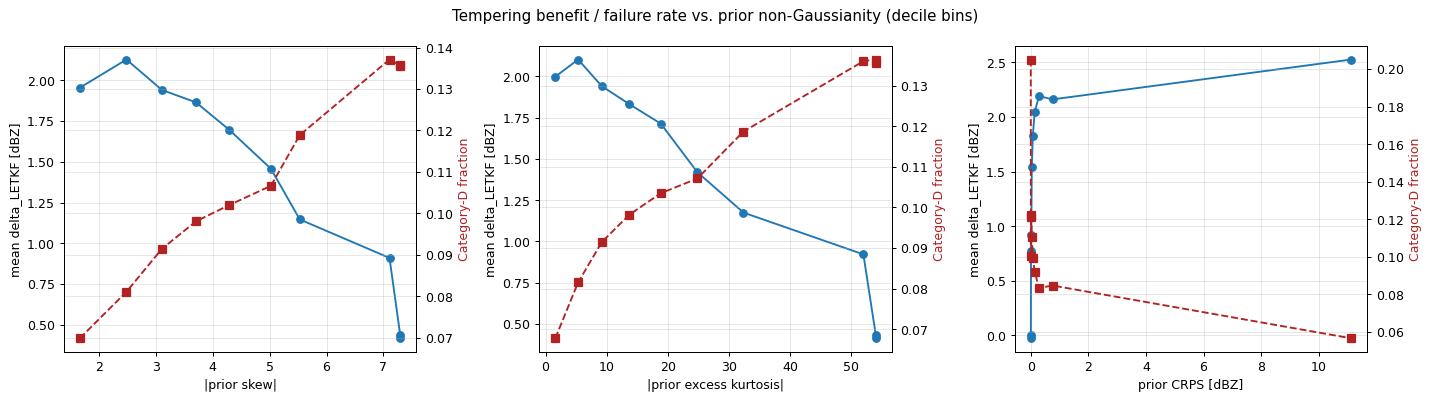

In [16]:

tier2j = tier2.merge(
    prior_metrics[['event', 'lead_time', 'tm', 'i', 'j', 'k', 'skew_f', 'kurt_f', 'crps_f']],
    on=['event', 'lead_time', 'tm', 'i', 'j', 'k'], how='left')

print("Join match rate (non-null skew_f):", tier2j['skew_f'].notna().mean())

tenkf2 = tier2j[(tier2j.method == 'TEnKF') & (tier2j.ntemp > 1)].copy()
tenkf2['abs_skew_f'] = tenkf2['skew_f'].abs()
tenkf2['abs_kurt_f'] = tenkf2['kurt_f'].abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, lbl in zip(axes, ['abs_skew_f', 'abs_kurt_f', 'crps_f'],
                         ['|prior skew|', '|prior excess kurtosis|', 'prior CRPS [dBZ]']):
    valid = tenkf2[col].notna() & tenkf2['delta_letkf'].notna()
    sub = tenkf2[valid]
    if len(sub) == 0:
        continue
    bins = np.nanpercentile(sub[col], np.linspace(0, 100, 11))
    bins = np.unique(bins)
    sub = sub.copy()
    sub['bin'] = pd.cut(sub[col], bins, include_lowest=True)
    g = sub.groupby('bin').agg(mean_delta_letkf=('delta_letkf', 'mean'),
                                frac_D=('category', lambda s: (s == 'D').mean()),
                                mid=(col, 'median'))
    ax.plot(g['mid'], g['mean_delta_letkf'], 'o-', label='mean delta_LETKF')
    ax2 = ax.twinx()
    ax2.plot(g['mid'], g['frac_D'], 's--', color='firebrick', label='frac Category-D')
    ax.set_xlabel(lbl); ax.set_ylabel('mean delta_LETKF [dBZ]')
    ax2.set_ylabel('Category-D fraction', color='firebrick')
fig.suptitle('Tempering benefit / failure rate vs. prior non-Gaussianity (decile bins)')
plt.tight_layout()
plt.show()


## 11. Spatial characterization

Adapts `build_obs_reference` / `plot_spatial_drmse_variable` from
`Notebooks/S4_LOC_Scale_Comparison.ipynb` (grouping dimension swapped from
`loc_scale` to `(ntemp, alpha_s)`) to map `delta_letkf`/`delta_prior` and the
Category-D failure zone spatially, with observed-reflectivity contour
overlays for storm context.

<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

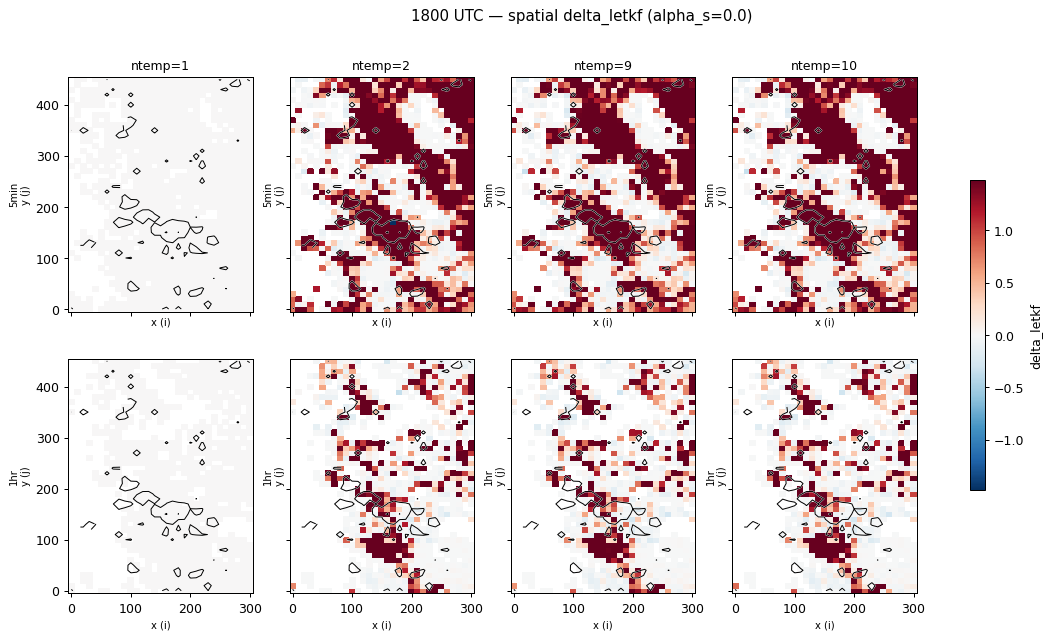

<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

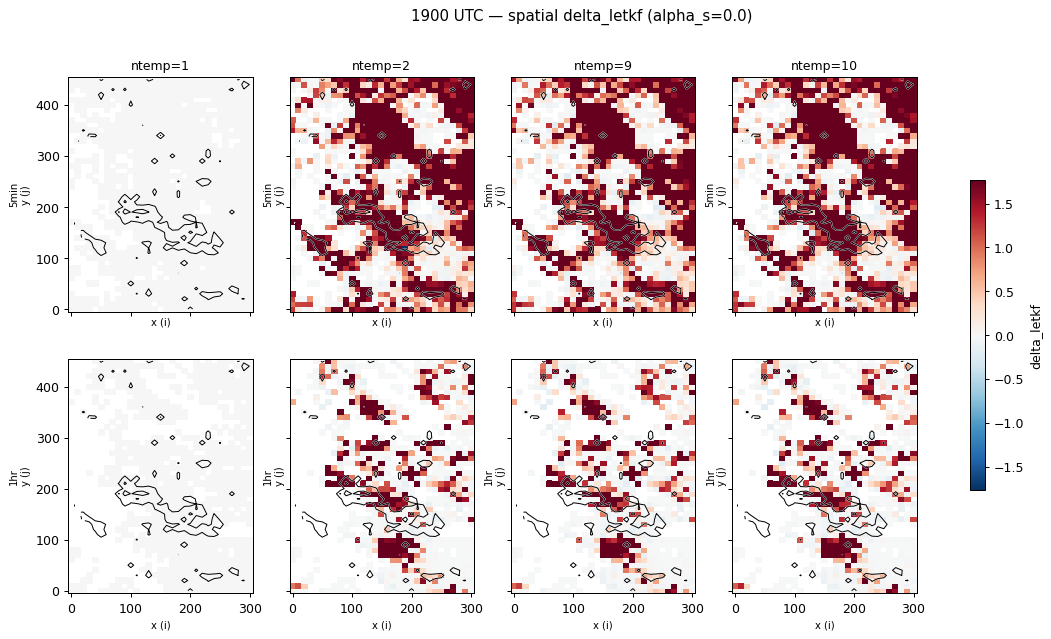

<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

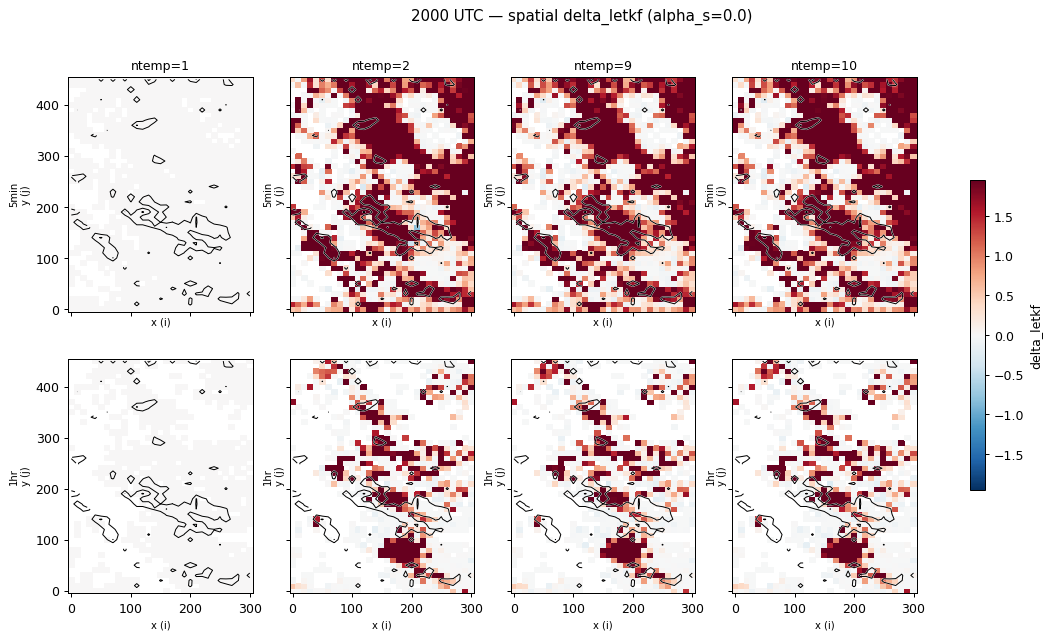

In [17]:

def build_obs_reference(df_ref, stride=20):
    i_idx = (np.array(df_ref["i"]) / stride).astype(int)
    j_idx = (np.array(df_ref["j"]) / stride).astype(int)
    k_idx = np.array(df_ref["k"]).astype(int)
    shape = (i_idx.max() + 1, j_idx.max() + 1, k_idx.max() + 1)
    vol = np.full(shape, np.nan)
    vol[i_idx, j_idx, k_idx] = df_ref["yo_clean"]
    max_yo_2d = np.nanmax(vol, axis=2)
    i_coords = np.arange(shape[0]) * stride
    j_coords = np.arange(shape[1]) * stride
    return i_coords, j_coords, max_yo_2d


def plot_spatial_metric(df, value_col, event, stride=10, cmap='RdBu_r', vcenter=0, agg='mean'):
    '''One figure per event: rows=lead_time, cols=REP_NTEMP (at REP_ALPHA[0]).'''
    sub_event = df[(df.event == event) & (df.method == 'TEnKF') &
                    (df.ntemp.isin(REP_NTEMP)) &
                    ((df.ntemp == 1) | np.isclose(df.alpha_s, REP_ALPHA[0]))]
    if len(sub_event) == 0:
        print("no data for event", event); return
    i_coords, j_coords, max_yo_2d = build_obs_reference(sub_event, stride=stride)

    vmax = sub_event[value_col].abs().quantile(0.95)
    vmax = max(vmax, 1e-6)
    norm = mcolors.TwoSlopeNorm(vcenter=vcenter, vmin=vcenter - vmax, vmax=vcenter + vmax) if cmap == 'RdBu_r' else None

    fig, axes = plt.subplots(len(LEAD_TIMES), len(REP_NTEMP), figsize=(3.8 * len(REP_NTEMP), 3.8 * len(LEAD_TIMES)),
                              sharex=True, sharey=True, squeeze=False)
    im = None
    for ri, lt in enumerate(LEAD_TIMES):
        for ci, nt in enumerate(REP_NTEMP):
            ax = axes[ri][ci]
            sub = sub_event[(sub_event.lead_time == lt) & (sub_event.ntemp == nt)]
            if len(sub) == 0:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
                continue
            i_idx = (np.array(sub['i']) / stride).astype(int)
            j_idx = (np.array(sub['j']) / stride).astype(int)
            k_idx = np.array(sub['k']).astype(int)
            shp = (max(i_idx.max() + 1, i_coords.size), max(j_idx.max() + 1, j_coords.size), k_idx.max() + 1)
            acc = np.zeros(shp); cnt = np.zeros(shp, dtype=int)
            vals = np.array(sub[value_col])
            finite = np.isfinite(vals)
            np.add.at(acc, (i_idx[finite], j_idx[finite], k_idx[finite]), vals[finite])
            np.add.at(cnt, (i_idx[finite], j_idx[finite], k_idx[finite]), 1)
            vol = np.where(cnt > 0, acc / cnt, np.nan)
            map2d = np.nanmean(vol, axis=2)
            im = ax.pcolormesh(i_coords, j_coords, map2d[:len(i_coords), :len(j_coords)].T,
                                cmap=cmap, norm=norm, shading='auto')
            ax.contour(i_coords, j_coords, max_yo_2d.T, levels=[20, 50], colors='black', linewidths=0.8, zorder=10)
            ax.contour(i_coords, j_coords, max_yo_2d.T, levels=[20, 50], colors='white', linewidths=1.3, zorder=5)
            if ri == 0:
                ax.set_title(f'ntemp={nt}', fontsize=10)
            ax.set_ylabel(f'{lt}\ny (j)', fontsize=8)
            ax.set_xlabel('x (i)', fontsize=8)
    if im is not None:
        fig.colorbar(im, ax=axes, shrink=0.6, label=value_col)
    fig.suptitle(f'{event} UTC — spatial {value_col} (alpha_s={REP_ALPHA[0]})')
    plt.show()


for event in EVENTS:
    plot_spatial_metric(tier2, 'delta_letkf', event, stride=10)


<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

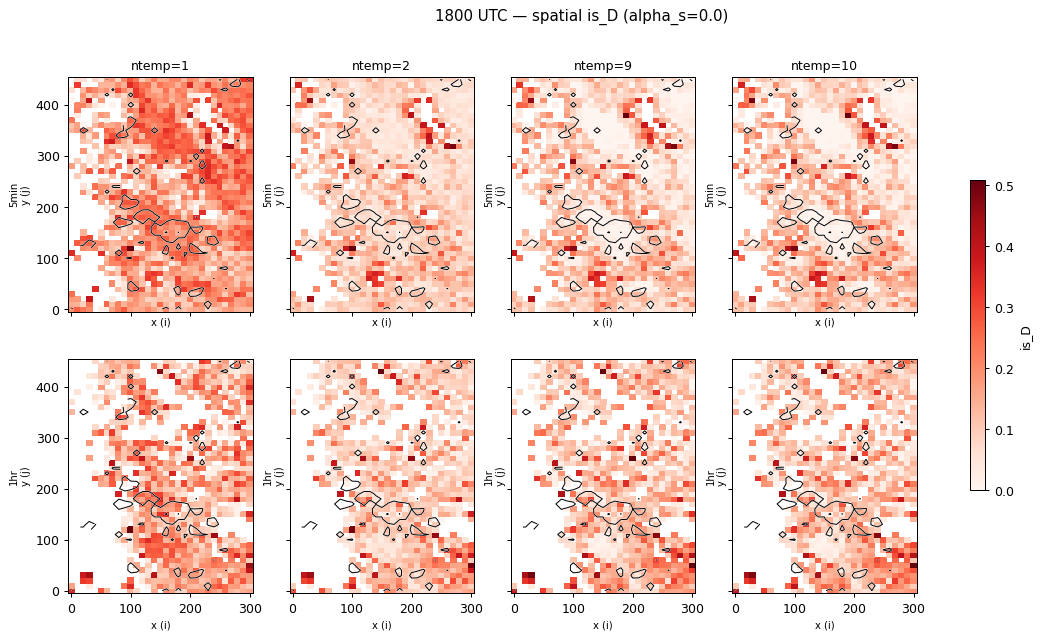

<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

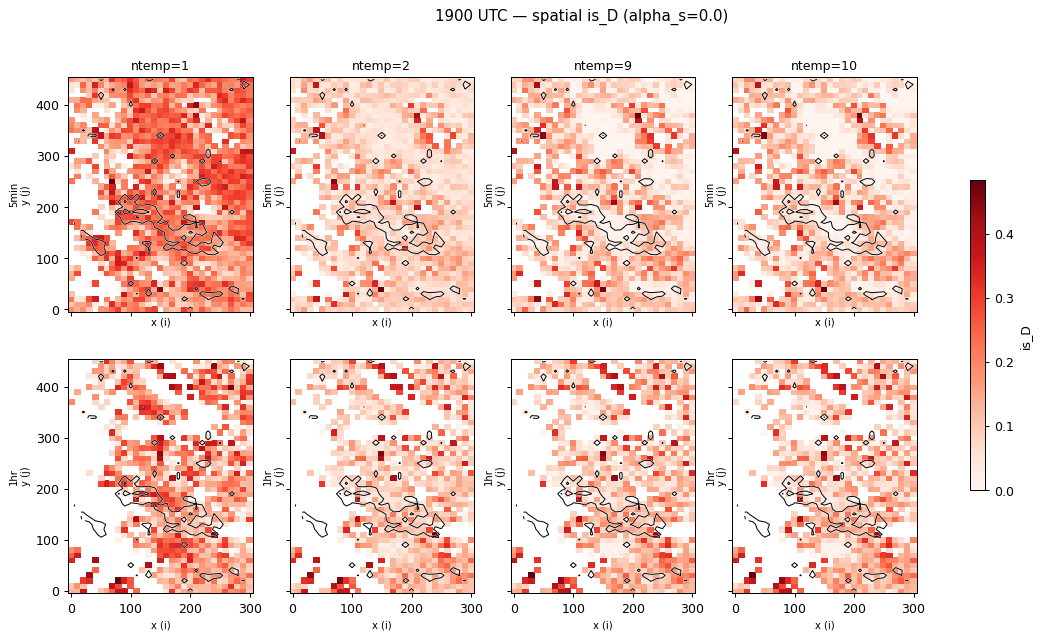

<ipython-input-1-ef65c6e2906d>:8: RuntimeWarning: All-NaN slice encountered
  max_yo_2d = np.nanmax(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e2906d>:47: RuntimeWarning: Mean of empty slice
  map2d = np.nanmean(vol, axis=2)
<ipython-input-1-ef65c6e2906d>:46: RuntimeWarning: invalid value encountered in true_divide
  vol = np.where(cnt > 0, acc / cnt, np.nan)
<ipython-input-1-ef65c6e

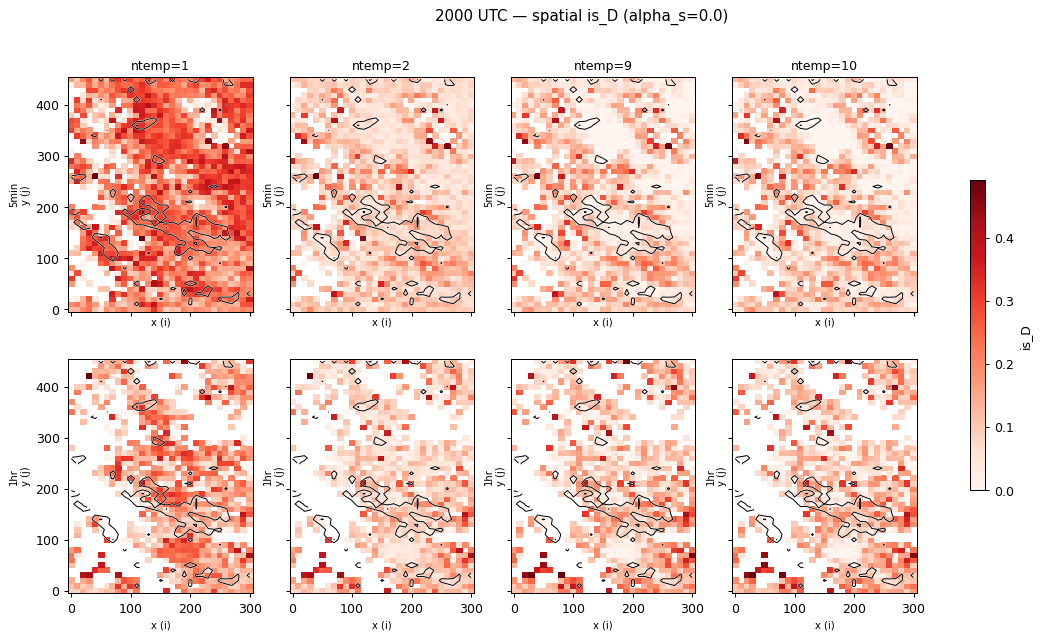

In [18]:

for event in EVENTS:
    plot_spatial_metric(tier2.assign(is_D=(tier2.category == 'D').astype(float)),
                         'is_D', event, stride=10, cmap='Reds', vcenter=None)


## 12. 5min vs 1hr prior comparison

First verify the premise: does the 1hr-lead prior really have larger
spread and more non-Gaussianity than the 5min-lead prior? **Restricted to
QC-passing points** (prior reflectivity variance > 0, i.e. `recon_spread_f > 0`
— the exact sweep QC condition): the full candidate grid is dominated by
clear-air points where the ensemble is degenerate (especially for the 1hr
prior), which would dilute the averages. The QC *fraction* itself is reported
as a coverage diagnostic — the 1hr prior keeps storm signal over far less of
the domain. Caveat: the QC point sets differ between lead times by
construction, so this compares each prior *where it has signal*, not at
identical locations. Then test the consequence: is tempering's benefit over
LETKF (`delta_letkf`) larger under the 1hr condition? Only 3 event-pairs —
report the actual paired numbers, not a formal significance test that would
be meaningless at n=3.

   event lead_time  mean_spread_f  mean_abs_skew_f  mean_abs_kurt_f  mean_crps_f
0   1800      5min       3.170327         4.380997        23.031487     0.985448
1   1800       1hr       0.833818         5.672663        36.058659     0.199014
2   1900      5min       3.496036         4.348429        22.959047     1.094173
3   1900       1hr       0.850350         5.633495        35.535603     0.204290
4   2000      5min       3.784894         4.316613        22.627638     1.176167
5   2000       1hr       1.043862         5.485385        33.926083     0.259464


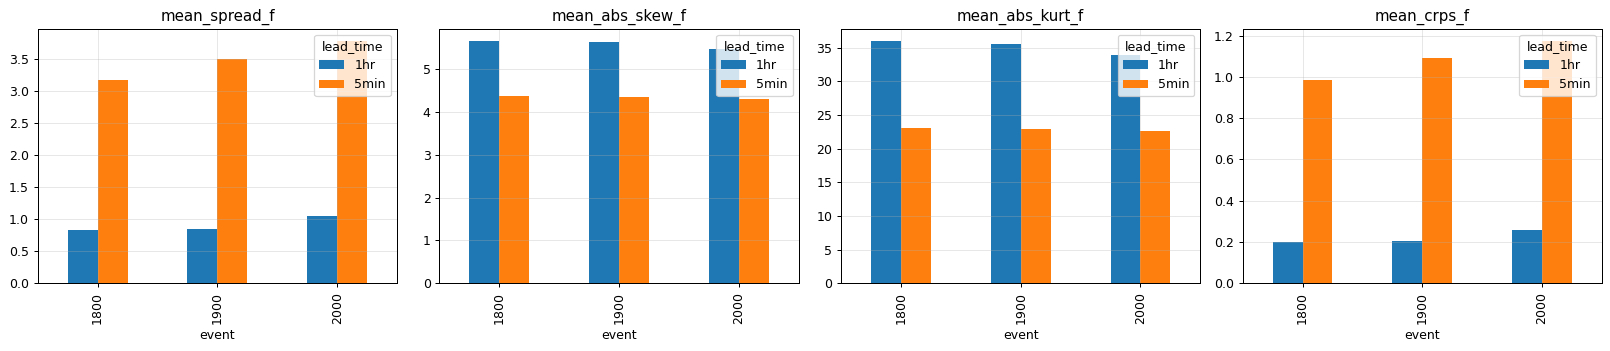

In [19]:
premise_rows = []
for event in EVENTS:
    for lt in LEAD_TIMES:
        pm = prior_metrics[(prior_metrics.event == event) & (prior_metrics.lead_time == lt)]
        n_cand = pm.groupby('tm').size().mean()
        # QC restriction: prior reflectivity variance > 0 — identical to the sweep QC filter
        qc = pm[pm['recon_spread_f'] > 0.0].copy()
        qc['abs_skew'] = qc['skew_f'].abs()
        qc['abs_kurt'] = qc['kurt_f'].abs()
        # equal-weighted mean across truth members (same convention as Tier-1)
        per_tm = qc.groupby('tm').agg(
            n=('i', 'size'), spread=('recon_spread_f', 'mean'),
            skew=('abs_skew', 'mean'), kurt=('abs_kurt', 'mean'), crps=('crps_f', 'mean'))
        premise_rows.append(dict(
            event=event, lead_time=lt,
            mean_n_qc=per_tm['n'].mean(), qc_frac=per_tm['n'].mean() / n_cand,
            mean_spread_f=per_tm['spread'].mean(),
            mean_abs_skew_f=per_tm['skew'].mean(),
            mean_abs_kurt_f=per_tm['kurt'].mean(),
            mean_crps_f=per_tm['crps'].mean()))
premise_df = pd.DataFrame(premise_rows)
print("Premise check on QC-passing points only (prior refl. variance > 0):")
print(premise_df.round(3).to_string(index=False))
print("\nNote: averaging over ALL candidate points instead (incl. degenerate clear air)")
print("understates the 1hr prior's spread/CRPS — most of its domain has a collapsed ensemble,")
print("which is captured here by qc_frac instead of contaminating the conditional means.")

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, ['qc_frac', 'mean_spread_f', 'mean_abs_skew_f', 'mean_abs_kurt_f', 'mean_crps_f']):
    piv = premise_df.pivot(index='event', columns='lead_time', values=col)
    piv.plot.bar(ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

lead_time       1hr      5min  diff_1hr_minus_5min
event                                             
1800       0.838961  1.450986            -0.612025
1900       0.943791  1.569847            -0.626056
2000       1.163742  1.658123            -0.494381


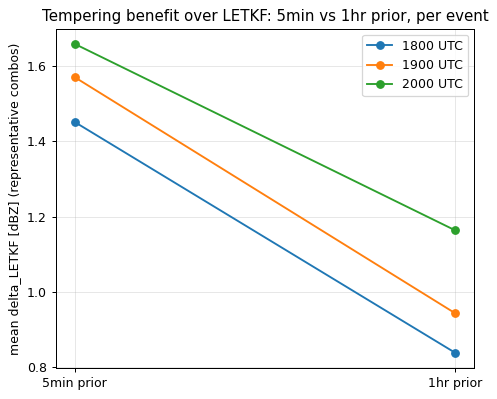


Hypothesis (tempering benefit larger under 1hr prior) supported in 0/3 events.


In [20]:

consequence_rows = []
for event in EVENTS:
    for lt in LEAD_TIMES:
        sub = tier2[(tier2.event == event) & (tier2.lead_time == lt) & (tier2.method == 'TEnKF') &
                    (tier2.ntemp.isin(REP_NTEMP)) & (tier2.ntemp > 1) &
                    (tier2.alpha_s.isin(REP_ALPHA))]
        consequence_rows.append(dict(event=event, lead_time=lt, mean_delta_letkf=sub['delta_letkf'].mean()))
cons_df = pd.DataFrame(consequence_rows)
piv = cons_df.pivot(index='event', columns='lead_time', values='mean_delta_letkf')
piv['diff_1hr_minus_5min'] = piv.get('1hr', np.nan) - piv.get('5min', np.nan)
print(piv.to_string())

fig, ax = plt.subplots(figsize=(6, 5))
for event in EVENTS:
    row = piv.loc[event]
    ax.plot([0, 1], [row['5min'], row['1hr']], 'o-', label=f'{event} UTC')
ax.set_xticks([0, 1]); ax.set_xticklabels(['5min prior', '1hr prior'])
ax.set_ylabel('mean delta_LETKF [dBZ] (representative combos)')
ax.set_title('Tempering benefit over LETKF: 5min vs 1hr prior, per event')
ax.legend()
plt.show()

n_events_supporting = (piv['diff_1hr_minus_5min'] > 0).sum()
print(f"\nHypothesis (tempering benefit larger under 1hr prior) supported in "
      f"{n_events_supporting}/{len(piv)} events.")


## 13. Final recommendation summary

In [21]:

print("=" * 70)
print("RECOMMENDATION SUMMARY")
print("=" * 70)
print(f"\nRepresentative ntemp values: {REP_NTEMP} (1=LETKF baseline)")
print(f"Representative alpha_s values: {REP_ALPHA}")
print(f"(Note: intended alpha_s=0.7 was never tested due to a config YAML typo; "
      f"alpha_s=7.0 was tested instead as an incidental extreme value.)")

print("\nHeadline numbers (representative combos, pooled per event/lead_time, "
      "mean +/- SE over 60 truth members):")
summary = final_combo[(final_combo.method == 'TEnKF') & (final_combo.ntemp.isin(REP_NTEMP)) &
                       ((final_combo.ntemp == 1) | final_combo.alpha_s.isin(REP_ALPHA))]
print(summary[['event', 'lead_time', 'ntemp', 'alpha_s', 'mean_delta_letkf', 'se_delta_letkf',
                'mean_delta_prior', 'frac_D', 'n_tm']].sort_values(['event', 'lead_time', 'ntemp']).to_string())

print("\nCaveats:")
print("- odd/even ntemp parity oscillation (test/diagnose_nt_parity.py) — compare within parity, not across")
print("- alpha_s=0.7 gap / alpha_s=7.0 extra value from the config YAML typo")
print("- posterior CRPS/skew/kurt not yet available (pending cluster rerun) — Section 14")
print(f"- 5min-vs-1hr hypothesis supported in {n_events_supporting}/3 events (see Section 12)")


RECOMMENDATION SUMMARY

Representative ntemp values: [1, 2, 9, 10] (1=LETKF baseline)
Representative alpha_s values: [0.0, 7.0]
(Note: intended alpha_s=0.7 was never tested due to a config YAML typo; alpha_s=7.0 was tested instead as an incidental extreme value.)

Headline numbers (representative combos, pooled per event/lead_time, mean +/- SE over 60 truth members):
     event lead_time  ntemp  alpha_s  mean_delta_letkf  se_delta_letkf  mean_delta_prior    frac_D  n_tm
1     1800       1hr      1      0.0          0.000000        0.000000         -0.578081  0.214383    60
2     1800       1hr      1      0.1          0.000000        0.000000         -0.578081  0.214383    60
3     1800       1hr      1      0.2          0.000000        0.000000         -0.578081  0.214383    60
4     1800       1hr      1      0.3          0.000000        0.000000         -0.578081  0.214383    60
5     1800       1hr      1      0.5          0.000000        0.000000         -0.578081  0.214383    60


## 14. Placeholder — posterior CRPS/skew/kurt (pending rerun)

Once the cluster rerun lands, `WS_tune_5min_*` sweep npz files will also
contain `crps_f/a_point_obs`, `skew_f/a_point_obs`, `kurt_f/a_point_obs`
(and per-variable variants) — see `compute_single_obs_metrics` in
`src/da/metrics.py:110-239`. This section is gated on their presence so the
notebook can be re-run largely as-is: it would repeat Section 10's
non-Gaussianity analysis using the *posterior* skew/kurt/CRPS instead of the
prior's, directly testing whether tempering actually reduces posterior
non-Gaussianity where it wins, not just RMSE.

In [22]:

_probe_f = sorted(glob.glob(os.path.join(CONFIGS[(1800, '5min')]['sweep_dir'], "*_sweep_*_tm00.npz")))[0]
with np.load(_probe_f) as _d:
    _has_posterior_crps = 'crps_a_point_obs' in _d.files

if not _has_posterior_crps:
    print("Posterior crps/skew/kurt columns not yet present on disk — pending cluster rerun.")
    print("Re-run this notebook (Section 1 onward, clearing the CACHE_DIR pickles first) once they land;")
    print("then extend Section 4's POINT_COLS/COMBO_COLS and repeat Section 10 on the posterior side.")
else:
    print("Posterior crps/skew/kurt columns are present — extend the loader and repeat Section 10 here.")


Posterior crps/skew/kurt columns not yet present on disk — pending cluster rerun.
Re-run this notebook (Section 1 onward, clearing the CACHE_DIR pickles first) once they land;
then extend Section 4's POINT_COLS/COMBO_COLS and repeat Section 10 on the posterior side.
